In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from scipy.signal import savgol_filter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("final_data.csv", index_col=0, parse_dates=True)

In [3]:
df.isna().sum()

Gold              0
DXY               0
Real_Yield_10Y    0
Breakeven_10Y     0
Fed_Funds         0
WTI_Oil           0
SP500             0
VIX               0
CPI_YoY           0
M2_YoY            0
dtype: int64

In [4]:
df["log_price"] = np.log(df["Gold"])
df["t"] = np.arange(len(df))

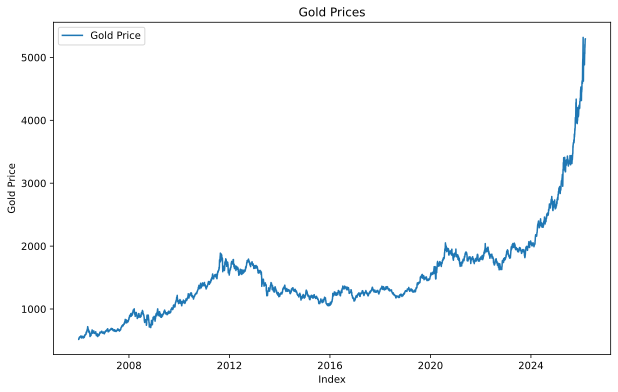

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df["Gold"], label="Gold Price")
plt.xlabel("Index")  # or use df.index if it has datetime
plt.ylabel("Gold Price")
plt.title("Gold Prices")
plt.legend()
plt.show()

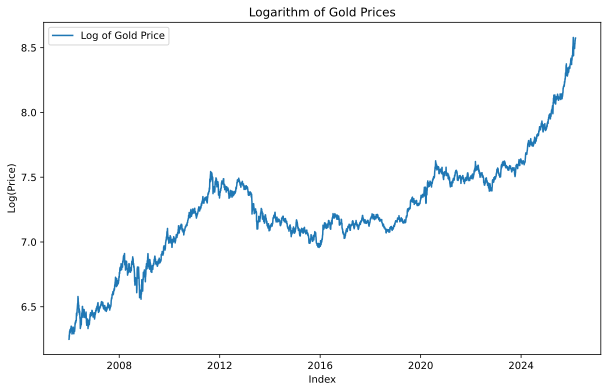

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df["log_price"], label="Log of Gold Price")
plt.xlabel("Index")  # or use df.index if it has datetime
plt.ylabel("Log(Price)")
plt.title("Logarithm of Gold Prices")
plt.legend()
plt.show()

In [7]:
forecast_horizon = 365

start_index = len(df) - forecast_horizon - 1

In [8]:
"""
predictions = []
actuals = []
dates = []

for i in range(start_index, len(df) - 1):
    
    percent_complete = (i - start_index + 1) / (len(df) - start_index - 1) * 100
    print(f"\rProgress: {percent_complete:.2f}%", end="")
    
    # Data available up to time t
    train_data = df.iloc[:i+1]
    
    # ----------------------------
    # STEP 1: Fit Linear Trend
    # ----------------------------
    X_trend = train_data[["t"]]
    y_trend = train_data["log_price"]
    
    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)
    
    train_data["trend"] = trend_model.predict(X_trend)
    train_data["residual"] = train_data["log_price"] - train_data["trend"]
    
    # ----------------------------
    # STEP 2: Fit ARMA to Residual
    # ----------------------------
    arma_model = ARIMA(train_data["residual"], order=(1,0,1))
    arma_fitted = arma_model.fit()
    
    # ----------------------------
    # STEP 3: Forecast Next Day
    # ----------------------------
    next_t = np.array([[train_data["t"].iloc[-1] + 1]])
    trend_forecast = trend_model.predict(next_t)[0]
    
    residual_forecast = arma_fitted.forecast(steps=1).iloc[0]
    
    log_price_forecast = trend_forecast + residual_forecast
    price_forecast = np.exp(log_price_forecast)
    
    # Store prediction and actual
    actual_price = df["Gold"].iloc[i+1]
    
    predictions.append(price_forecast)
    actuals.append(actual_price)
    dates.append(df.index[i+1])
    
print("\nDone!")
"""

'\npredictions = []\nactuals = []\ndates = []\n\nfor i in range(start_index, len(df) - 1):\n\n    percent_complete = (i - start_index + 1) / (len(df) - start_index - 1) * 100\n    print(f"\rProgress: {percent_complete:.2f}%", end="")\n\n    # Data available up to time t\n    train_data = df.iloc[:i+1]\n\n    # ----------------------------\n    # STEP 1: Fit Linear Trend\n    # ----------------------------\n    X_trend = train_data[["t"]]\n    y_trend = train_data["log_price"]\n\n    trend_model = LinearRegression()\n    trend_model.fit(X_trend, y_trend)\n\n    train_data["trend"] = trend_model.predict(X_trend)\n    train_data["residual"] = train_data["log_price"] - train_data["trend"]\n\n    # ----------------------------\n    # STEP 2: Fit ARMA to Residual\n    # ----------------------------\n    arma_model = ARIMA(train_data["residual"], order=(1,0,1))\n    arma_fitted = arma_model.fit()\n\n    # ----------------------------\n    # STEP 3: Forecast Next Day\n    # -------------------

In [9]:
"""
results = pd.DataFrame({
    "Date": dates,
    "Actual": actuals,
    "Predicted": predictions
}).set_index("Date")
"""

'\nresults = pd.DataFrame({\n    "Date": dates,\n    "Actual": actuals,\n    "Predicted": predictions\n}).set_index("Date")\n'

In [10]:
"""
results["APE"] = np.abs(
    (results["Actual"] - results["Predicted"]) / results["Actual"]
)

mape = results["APE"].mean() * 100

print("MAPE over last 1 year: {:.4f}%".format(mape))
"""

'\nresults["APE"] = np.abs(\n    (results["Actual"] - results["Predicted"]) / results["Actual"]\n)\n\nmape = results["APE"].mean() * 100\n\nprint("MAPE over last 1 year: {:.4f}%".format(mape))\n'

## Auto Arima

In [11]:
from pmdarima.arima import auto_arima

# Use a large training period, e.g., last 5–10 years
residuals = df["log_price"] - LinearRegression().fit(df[["t"]], df["log_price"]).predict(df[["t"]])

tuned_model = auto_arima(
    residuals,
    stationary=True,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    max_p=10,
    max_q=10,
    max_d=0,
    trace = True,
    n_jobs=-1
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=5.04 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-1470.310, Time=0.37 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-11275.636, Time=0.81 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1472.310, Time=0.18 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-47502.153, Time=0.70 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-47500.419, Time=0.74 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-47500.493, Time=2.06 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-19126.016, Time=1.96 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-47504.052, Time=0.40 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-11277.636, Time=0.61 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.33 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-47502.323, Time=0.50 sec
 ARIMA(1,0,2)(0,0,0)[0]            

In [12]:
# Save best hyperparameters
p, d, q = tuned_model.order
print("Selected ARIMA order:", (p,d,q))
print("AIC:", tuned_model.aic())

Selected ARIMA order: (2, 0, 2)
AIC: -47509.800495200165


In [13]:
predictions = []
actuals = []
dates = []

for i in range(start_index, len(df) - 1):
    
    percent_complete = (i - start_index + 1) / (len(df) - start_index - 1) * 100
    print(f"\rProgress: {percent_complete:.2f}%", end="")
    
    # Data available up to time t
    train_data = df.iloc[:i+1]
    
    # ----------------------------
    # STEP 1: Fit Linear Trend
    # ----------------------------
    X_trend = train_data[["t"]]
    y_trend = train_data["log_price"]
    
    trend_model = LinearRegression()
    trend_model.fit(X_trend, y_trend)
    
    train_data["trend"] = trend_model.predict(X_trend)
    train_data["residual"] = train_data["log_price"] - train_data["trend"]
    
    # ----------------------------
    # STEP 2: Fit ARMA to Residual
    # ----------------------------
    arma_model = ARIMA(train_data["residual"], order=(p,d,q))
    arma_fitted = arma_model.fit()
    
    # ----------------------------
    # STEP 3: Forecast Next Day
    # ----------------------------
    next_t = np.array([[train_data["t"].iloc[-1] + 1]])
    trend_forecast = trend_model.predict(next_t)[0]
    
    residual_forecast = arma_fitted.forecast(steps=1).iloc[0]
    
    log_price_forecast = trend_forecast + residual_forecast
    price_forecast = np.exp(log_price_forecast)
    
    # Store prediction and actual
    actual_price = df["Gold"].iloc[i+1]
    
    predictions.append(price_forecast)
    actuals.append(actual_price)
    dates.append(df.index[i+1])
    
print("\nDone!")

Progress: 55.89%

KeyboardInterrupt: 